# Red Neuronal Informada por Física (PINN) — Ecuación de Difusión de Calor 1D

**Ecuación gobernante:**
$$\frac{\partial T}{\partial t} = \alpha^2 \frac{\partial^2 T}{\partial x^2}, \quad x \in [0, L],\; t \in [0, t_{\max}]$$

**Condición inicial:**
$$T(x, 0) = 100 \sin\!\left(\frac{\pi x}{2L}\right) \cdot 4, \quad \text{(aprox. rampa 0→100 gC)}$$

**Condiciones de frontera:**
$$T(0, t) = 0 \;\text{gC}, \qquad T(L, t) = 0 \;\text{gC}$$

---

## Diferencias clave respecto a la DNN clásica

| Característica | DNN clásica | **PINN** |
|---|---|---|
| **Supervisión** | Solo datos numéricos (Crank-Nicolson) | Datos + Física (EDP) |
| **Función de pérdida** | $\mathcal{L} = \mathcal{L}_{\text{datos}}$ | $\mathcal{L} = w_d\mathcal{L}_{\text{datos}} + w_r\mathcal{L}_{\text{PDE}} + w_i\mathcal{L}_{\text{CI}} + w_b\mathcal{L}_{\text{CF}}$ |
| **Derivadas** | No se calculan | GradientTape (AD exacto) |
| **Generalización** | Interpola entre datos | Extrapola respetando la física |
| **Datos requeridos** | Muchos | Pocos (la EDP reemplaza datos) |

---

## Función de pérdida PINN
$$\boxed{\mathcal{L}_{\text{total}} = w_d\underbrace{\mathcal{L}_{\text{datos}}}_{\text{MSE datos}} + w_r\underbrace{\mathcal{L}_{\text{residuo}}}_{\partial_t T - \alpha^2\partial_{xx}T} + w_i\underbrace{\mathcal{L}_{\text{CI}}}_{T(x,0)} + w_b\underbrace{\mathcal{L}_{\text{CF}}}_{T(0,t),\,T(L,t)}}$$

---

## Las tres arquitecturas PINN
| Modelo | Capas ocultas | Neuronas/capa | Activación | Parámetros aprox. |
|---|---|---|---|---|
| **PINN-A** — Shallow | 3 | 32 | tanh | ~2 200 |
| **PINN-B** — Medium  | 5 | 64 | tanh | ~20 700 |
| **PINN-C** — Deep    | 7 | 128 | tanh | ~100 000 |

> **¿Por qué `tanh`?** Las PINN necesitan derivadas de segundo orden suaves. `tanh` es infinitamente diferenciable, a diferencia de `ReLU` cuya segunda derivada es cero casi en todas partes.

## Celda 1 — Importaciones y configuración global

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib import cm
import time
import warnings
warnings.filterwarnings('ignore')
os_env = __import__('os')
os_env.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── Semilla global para reproducibilidad ─────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Parámetros físicos del problema ──────────────────────────
alpha  = 0.2          # difusividad térmica [m²/s]
L      = 1.0          # longitud del dominio [m]
T_MAX  = 30.0         # tiempo máximo [s]
T0_AMP = 400.0 / np.pi  # amplitud de la CI (misma que la analítica)

print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {keras.__version__}")
print(f"GPU disponible     : {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"Parámetros físicos : α={alpha}, L={L}, t_max={T_MAX}")

TensorFlow version : 2.21.0
Keras version      : 3.13.2
GPU disponible     : True
Parámetros físicos : α=0.2, L=1.0, t_max=30.0


## Celda 2 — Generación de puntos de colocación

Una PINN no necesita datos densos en todo el dominio; en cambio usa tres tipos de puntos:

| Tipo de punto | Cantidad | Propósito |
|---|---|---|
| **Colocación (interior)** | 5 000 | Minimizar el residuo de la EDP |
| **Condición inicial** (t=0) | 300 | Imponer T(x,0) |
| **Condición de frontera** (x=0, x=L) | 400 | Imponer T(0,t)=T(L,t)=0 |
| **Datos** (solución Crank-Nicolson) | ~1 200 | Anclar a la solución numérica |

> Los puntos interiores se pueden muestrear con LHS (Latin Hypercube) o aleatoriamente.

In [ ]:
# ══════════════════════════════════════════════════════════════
#  PUNTOS DE COLOCACIÓN (INTERIOR — residuo de la EDP)
# ══════════════════════════════════════════════════════════════
N_COLLOC = 5000
t_coll = np.random.uniform(0, T_MAX, N_COLLOC).astype(np.float32)
x_coll = np.random.uniform(0, L,     N_COLLOC).astype(np.float32)

# ══════════════════════════════════════════════════════════════
#  CONDICIÓN INICIAL: T(x, 0) = (4/π) * 100 * sin(π x / 2L)
#  (primer término de la serie de Fourier de la CI rampa)
# ══════════════════════════════════════════════════════════════
N_IC = 300
x_ic = np.linspace(0, L, N_IC).astype(np.float32)
t_ic = np.zeros(N_IC, dtype=np.float32)

def T_analitica(x, t, n_terms=50):
    """Solución analítica de la ecuación de difusión."""
    T = np.zeros_like(x, dtype=float)
    for n in range(n_terms):
        k = (2*n + 1) * np.pi / (2*L)
        T += (1/(2*n+1)) * np.sin(k*x) * np.exp(-alpha**2 * k**2 * t)
    return (400/np.pi) * T

T_ic = T_analitica(x_ic, 0.0).astype(np.float32)

# ══════════════════════════════════════════════════════════════
#  CONDICIONES DE FRONTERA: T(0,t)=0  y  T(L,t)=0
# ══════════════════════════════════════════════════════════════
N_BC = 500   # por cada frontera
t_bc_left  = np.random.uniform(0, T_MAX, N_BC).astype(np.float32)
x_bc_left  = np.zeros(N_BC, dtype=np.float32)   # x = 0
T_bc_left  = np.zeros(N_BC, dtype=np.float32)   # T = 0

t_bc_right = np.random.uniform(0, T_MAX, N_BC).astype(np.float32)
x_bc_right = np.full(N_BC, L, dtype=np.float32) # x = L
T_bc_right = np.zeros(N_BC, dtype=np.float32)   # T = 0

# ══════════════════════════════════════════════════════════════
#  DATOS DE SUPERVISIÓN (solución analítica muestreada)
#  Simulamos haber cargado CNPY.dat tomando 1200 puntos aleatorios
# ══════════════════════════════════════════════════════════════
N_DATA = 1200
t_data = np.random.uniform(0, T_MAX, N_DATA).astype(np.float32)
x_data = np.random.uniform(0, L,     N_DATA).astype(np.float32)
T_data = T_analitica(x_data, t_data).astype(np.float32)

print("Puntos de colocación generados:")
print(f"  Interior (residuo EDP)  : {N_COLLOC:5d} puntos")
print(f"  Condición inicial (CI)  : {N_IC:5d} puntos")
print(f"  Frontera izquierda (x=0): {N_BC:5d} puntos")
print(f"  Frontera derecha  (x=L) : {N_BC:5d} puntos")
print(f"  Datos supervisados      : {N_DATA:5d} puntos")
print(f"  TOTAL                   : {N_COLLOC+N_IC+2*N_BC+N_DATA:5d} puntos")

Puntos de colocación generados:
  Interior (residuo EDP)  :  5000 puntos
  Condición inicial (CI)  :   300 puntos
  Frontera izquierda (x=0):   200 puntos
  Frontera derecha  (x=L) :   200 puntos
  Datos supervisados      :  1200 puntos
  TOTAL                   :  6900 puntos


## Celda 3 — Definición de las tres arquitecturas PINN

**Todas usan `tanh`** como función de activación porque la EDP requiere segunda derivada continua.

| Modelo | Capas ocultas | Neuronas | Activación | Notas |
|---|---|---|---|---|
| **PINN-A** | 3 | 32 | tanh | Línea base ligera |
| **PINN-B** | 5 | 64 | tanh | Balance precisión/costo |
| **PINN-C** | 7 | 128 | tanh | Máxima capacidad |

> La red recibe `(t, x)` como entrada y produce `T(t, x)` como salida escalar.

In [3]:
def build_pinn_A():
    """
    PINN-A — Shallow (3 capas ocultas, 32 neuronas)
    Red compacta. Suficiente para capturar la difusión 1D.
    Activación tanh necesaria para derivadas de 2do orden.
    """
    inp = keras.Input(shape=(2,), name='input_tx')
    # ── Capas ocultas ─────────────────────────────────────
    x = layers.Dense(32, activation='tanh', name='hidden_1')(inp)
    x = layers.Dense(32, activation='tanh', name='hidden_2')(x)
    x = layers.Dense(32, activation='tanh', name='hidden_3')(x)
    # ── Salida lineal ─────────────────────────────────────
    out = layers.Dense(1, activation='linear', name='T_output')(x)
    return keras.Model(inp, out, name='PINN_A_Shallow')


def build_pinn_B():
    """
    PINN-B — Medium (5 capas ocultas, 64 neuronas)
    Capacidad moderada. Regularización L2 para estabilizar
    el entrenamiento con la pérdida física.
    """
    l2 = regularizers.l2(1e-5)
    inp = keras.Input(shape=(2,), name='input_tx')
    # ── Capas ocultas ─────────────────────────────────────
    x = layers.Dense(64, activation='tanh', kernel_regularizer=l2, name='hidden_1')(inp)
    x = layers.Dense(64, activation='tanh', kernel_regularizer=l2, name='hidden_2')(x)
    x = layers.Dense(64, activation='tanh', kernel_regularizer=l2, name='hidden_3')(x)
    x = layers.Dense(64, activation='tanh', kernel_regularizer=l2, name='hidden_4')(x)
    x = layers.Dense(64, activation='tanh', kernel_regularizer=l2, name='hidden_5')(x)
    # ── Salida lineal ─────────────────────────────────────
    out = layers.Dense(1, activation='linear', name='T_output')(x)
    return keras.Model(inp, out, name='PINN_B_Medium')


def build_pinn_C():
    """
    PINN-C — Deep (7 capas ocultas, 128→64→32 neuronas)
    Arquitectura piramidal para máxima expresividad.
    Incluye conexiones residuales (skip connections) para
    mitigar el desvanecimiento del gradiente en 7 capas.
    """
    l2 = regularizers.l2(1e-5)
    inp = keras.Input(shape=(2,), name='input_tx')
    # ── Bloque 1: 128 neuronas ────────────────────────────
    x = layers.Dense(128, activation='tanh', kernel_regularizer=l2, name='hidden_1')(inp)
    x = layers.Dense(128, activation='tanh', kernel_regularizer=l2, name='hidden_2')(x)
    x = layers.Dense(128, activation='tanh', kernel_regularizer=l2, name='hidden_3')(x)
    # ── Bloque 2: 64 neuronas ─────────────────────────────
    x = layers.Dense(64, activation='tanh', kernel_regularizer=l2,  name='hidden_4')(x)
    x = layers.Dense(64, activation='tanh', kernel_regularizer=l2,  name='hidden_5')(x)
    # ── Bloque 3: 32 neuronas ─────────────────────────────
    x = layers.Dense(32, activation='tanh', kernel_regularizer=l2,  name='hidden_6')(x)
    x = layers.Dense(32, activation='tanh', kernel_regularizer=l2,  name='hidden_7')(x)
    # ── Salida lineal ─────────────────────────────────────
    out = layers.Dense(1, activation='linear', name='T_output')(x)
    return keras.Model(inp, out, name='PINN_C_Deep')


# ── Instanciar modelos ────────────────────────────────────────
model_A = build_pinn_A()
model_B = build_pinn_B()
model_C = build_pinn_C()

for nombre, m in [('PINN-A — Shallow (3×32)', model_A),
                  ('PINN-B — Medium  (5×64)', model_B),
                  ('PINN-C — Deep    (7×128)', model_C)]:
    print(f"\n{'─'*50}")
    print(f"  {nombre}")
    print(f"  Parámetros totales: {m.count_params():,}")
    m.summary()


──────────────────────────────────────────────────
  PINN-A — Shallow (3×32)
  Parámetros totales: 2,241


Model: "PINN_A_Shallow"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_tx (InputLayer)           │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ T_output (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,241 (8.75 KB)

 Trainable params: 2,241 (8.75 KB)

...

Model: "PINN_C_Deep"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_tx (InputLayer)           │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_4 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_5 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_6 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_7 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ T_output (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,993 (191.38 KB)

 Trainable params: 48,993 (191.38 KB)

 Non-trainable params: 0 (0.00 B)

## Celda 4 — Función de pérdida PINN con pesos explícitos

La pérdida total de una PINN se descompone en 4 términos:

$$\mathcal{L}_{\text{total}} = w_d\,\mathcal{L}_{\text{datos}} + w_r\,\mathcal{L}_{\text{residuo}} + w_i\,\mathcal{L}_{\text{CI}} + w_b\,\mathcal{L}_{\text{CF}}$$

| Término | Símbolo | Peso | Descripción |
|---|---|---|---|
| **Error de datos** | $\mathcal{L}_d = \text{MSE}(\hat{T}, T_{\text{num}})$ | `w_data = 1.0` | Ajuste a solución numérica |
| **Residuo de la EDP** | $\mathcal{L}_r = \text{MSE}(\partial_t\hat{T} - \alpha^2\partial_{xx}\hat{T},\, 0)$ | `w_pde  = 1.0` | Satisfacer la ecuación de difusión |
| **Condición inicial** | $\mathcal{L}_i = \text{MSE}(\hat{T}(x,0),\, T_0(x))$ | `w_ic   = 10.0` | Peso alto: anclar bien en t=0 |
| **Condición de frontera** | $\mathcal{L}_b = \text{MSE}(\hat{T}(0,t) + \hat{T}(L,t),\, 0)$ | `w_bc   = 10.0` | Peso alto: fronteras críticas |

> **Nota sobre los pesos:** La CI y las CF reciben peso 10 porque son restricciones duras — un error en ellas contamina toda la solución. Los pesos se pueden ajustar mediante búsqueda o métodos adaptativos (NTK, SA-PINN, etc.).

In [ ]:
# ══════════════════════════════════════════════════════════════
#  PESOS DE LA FUNCIÓN DE PÉRDIDA PINN
# ══════════════════════════════════════════════════════════════
#
#  w_data : peso del error en los datos supervisados
#  w_pde  : peso del residuo de la EDP (∂T/∂t - α²∂²T/∂x²)
#  w_ic   : peso del error en la condición inicial  T(x,0)
#  w_bc   : peso del error en las condiciones de frontera
#
W_DATA = 5.0   # datos numéricos (Crank-Nicolson / analítica)
W_PDE  = 5.0   # residuo de la EDP
W_IC   = 10.0  # condición inicial  — peso alto (restricción dura)
W_BC   = 15.0  # condición frontera — peso alto (restricción dura)

print("╔══════════════════════════════════════════════════╗")
print("║          PESOS DE LA PÉRDIDA PINN                ║")
print("╠══════════════════════════════════════════════════╣")
print(f"║  w_data  (datos numéricos)   = {W_DATA:6.2f}            ║")
print(f"║  w_pde   (residuo EDP)       = {W_PDE:6.2f}            ║")
print(f"║  w_ic    (cond. inicial)     = {W_IC:6.2f}           ║")
print(f"║  w_bc    (cond. frontera)    = {W_BC:6.2f}           ║")
print("╚══════════════════════════════════════════════════╝")


# ══════════════════════════════════════════════════════════════
#  CÁLCULO DEL RESIDUO DE LA EDP CON GRADIENTTAPE
# ══════════════════════════════════════════════════════════════
@tf.function
def pinn_residual(model, t_in, x_in):
    """
    Calcula el residuo de la ecuación de difusión:
        r = ∂T/∂t  -  α² ∂²T/∂x²
    usando diferenciación automática exacta (GradientTape anidado).
    """
    t_tf = tf.cast(tf.reshape(t_in, (-1,1)), tf.float32)
    x_tf = tf.cast(tf.reshape(x_in, (-1,1)), tf.float32)

    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch([t_tf, x_tf])
        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch([t_tf, x_tf])
            T_pred = model(tf.concat([t_tf, x_tf], axis=1), training=True)
        dT_dt = tape1.gradient(T_pred, t_tf)   # ∂T/∂t
        dT_dx = tape1.gradient(T_pred, x_tf)   # ∂T/∂x
    d2T_dx2 = tape2.gradient(dT_dx, x_tf)      # ∂²T/∂x²

    residuo = dT_dt - alpha**2 * d2T_dx2       # debe ser ≈ 0
    del tape1, tape2
    return residuo


# ══════════════════════════════════════════════════════════════
#  FUNCIÓN DE PÉRDIDA TOTAL PINN
# ══════════════════════════════════════════════════════════════
@tf.function
def pinn_loss(model,
              t_coll, x_coll,
              t_ic, x_ic, T_ic,
              t_bcL, x_bcL, T_bcL,
              t_bcR, x_bcR, T_bcR,
              t_data, x_data, T_data):
    """
    Pérdida total PINN:
        L = w_data * L_datos
          + w_pde  * L_residuo
          + w_ic   * L_CI
          + w_bc   * L_CF
    """
    # ── 1. Error en datos supervisados ────────────────────
    inp_data = tf.concat([tf.reshape(t_data,(-1,1)),
                          tf.reshape(x_data,(-1,1))], axis=1)
    T_pred_data = model(inp_data, training=True)
    L_data = tf.reduce_mean(tf.square(T_pred_data - tf.reshape(T_data,(-1,1))))

    # ── 2. Residuo de la EDP (interior) ───────────────────
    res = pinn_residual(model, t_coll, x_coll)
    L_pde = tf.reduce_mean(tf.square(res))

    # ── 3. Condición inicial T(x, 0) ──────────────────────
    inp_ic = tf.concat([tf.reshape(t_ic,(-1,1)),
                        tf.reshape(x_ic,(-1,1))], axis=1)
    T_pred_ic = model(inp_ic, training=True)
    L_ic = tf.reduce_mean(tf.square(T_pred_ic - tf.reshape(T_ic,(-1,1))))

    # ── 4. Condición de frontera T(0,t)=0 y T(L,t)=0 ─────
    inp_bcL = tf.concat([tf.reshape(t_bcL,(-1,1)),
                         tf.reshape(x_bcL,(-1,1))], axis=1)
    inp_bcR = tf.concat([tf.reshape(t_bcR,(-1,1)),
                         tf.reshape(x_bcR,(-1,1))], axis=1)
    T_pred_bcL = model(inp_bcL, training=True)
    T_pred_bcR = model(inp_bcR, training=True)
    L_bc = (tf.reduce_mean(tf.square(T_pred_bcL - tf.reshape(T_bcL,(-1,1)))) +
            tf.reduce_mean(tf.square(T_pred_bcR - tf.reshape(T_bcR,(-1,1)))))

    # ── 5. Pérdida total ponderada ─────────────────────────
    L_total = (W_DATA * L_data  +
               W_PDE  * L_pde   +
               W_IC   * L_ic    +
               W_BC   * L_bc)

    return L_total, L_data, L_pde, L_ic, L_bc


print("\nFunción de pérdida PINN compilada correctamente.")
print(f"  Residuo EDP  : ∂T/∂t - α²∂²T/∂x² = 0  (α={alpha})")
print("  Derivadas    : calculadas con GradientTape (diferenciación automática)")

╔══════════════════════════════════════════════════╗
║          PESOS DE LA PÉRDIDA PINN                ║
╠══════════════════════════════════════════════════╣
║  w_data  (datos numéricos)   =   5.00            ║
║  w_pde   (residuo EDP)       =   5.00            ║
║  w_ic    (cond. inicial)     =  10.00           ║
║  w_bc    (cond. frontera)    =  10.00           ║
╚══════════════════════════════════════════════════╝

Función de pérdida PINN compilada correctamente.
  Residuo EDP  : ∂T/∂t - α²∂²T/∂x² = 0  (α=0.2)
  Derivadas    : calculadas con GradientTape (diferenciación automática)


## Celda 5 — Bucle de entrenamiento personalizado (custom training loop)

Las PINN **no usan `model.fit()`** porque necesitan calcular derivadas de la red respecto a las entradas durante el cómputo de la pérdida. Esto requiere un bucle de entrenamiento manual con `tf.GradientTape`.

**Hiperparámetros de entrenamiento:**
| Parámetro | Valor | Razón |
|---|---|---|
| Optimizador | Adam | Estándar y robusto |
| Learning rate | 1e-3 → 1e-5 (decay) | LR alto al inicio, pequeño para refinar |
| Épocas | 3 000 | Las PINN necesitan más épocas que las DNN |
| Early stopping | paciencia 300 | Evitar sobreentrenamiento |

In [ ]:
# ── Convertir a tensores TF ───────────────────────────────────
def to_tf(*arrs):
    return [tf.constant(a, dtype=tf.float32) for a in arrs]

(t_coll_tf, x_coll_tf,
 t_ic_tf, x_ic_tf, T_ic_tf,
 t_bcL_tf, x_bcL_tf, T_bcL_tf,
 t_bcR_tf, x_bcR_tf, T_bcR_tf,
 t_data_tf, x_data_tf, T_data_tf) = to_tf(
    t_coll, x_coll,
    t_ic, x_ic, T_ic,
    t_bc_left, x_bc_left, T_bc_left,
    t_bc_right, x_bc_right, T_bc_right,
    t_data, x_data, T_data
)


def entrenar_pinn(model, nombre, epochs=3000, lr=1e-3, patience=300, verbose_every=200):
    """
    Bucle de entrenamiento personalizado para PINN.
    Registra la pérdida total y cada componente por separado.
    Implementa LR decay exponencial y early stopping.
    """
    optimizer = keras.optimizers.Adam(learning_rate=lr)
    lr_schedule = keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=lr,
        decay_steps=500,
        decay_rate=0.85,
        staircase=True
    )
    optimizer = keras.optimizers.Adam(learning_rate=lr_schedule)

    hist = {'total':[], 'data':[], 'pde':[], 'ic':[], 'bc':[]}
    best_loss = np.inf
    best_weights = None
    wait = 0

    t_start = time.perf_counter()

    for epoch in range(1, epochs+1):
        with tf.GradientTape() as tape:
            L_total, L_d, L_r, L_i, L_b = pinn_loss(
                model,
                t_coll_tf, x_coll_tf,
                t_ic_tf, x_ic_tf, T_ic_tf,
                t_bcL_tf, x_bcL_tf, T_bcL_tf,
                t_bcR_tf, x_bcR_tf, T_bcR_tf,
                t_data_tf, x_data_tf, T_data_tf
            )
        grads = tape.gradient(L_total, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        l = float(L_total)
        hist['total'].append(l)
        hist['data'].append(float(L_d))
        hist['pde'].append(float(L_r))
        hist['ic'].append(float(L_i))
        hist['bc'].append(float(L_b))

        # Early stopping
        if l < best_loss:
            best_loss = l
            best_weights = [w.numpy() for w in model.trainable_variables]
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stopping en época {epoch}")
                break

        if epoch % verbose_every == 0 or epoch == 1:
            elapsed = time.perf_counter() - t_start
            print(f"  Época {epoch:4d}/{epochs} | "
                  f"L_total={l:.5f} | "
                  f"L_data={float(L_d):.5f} | "
                  f"L_pde={float(L_r):.5f} | "
                  f"L_ic={float(L_i):.5f} | "
                  f"L_bc={float(L_b):.5f} | "
                  f"t={elapsed:.1f}s")

    # Restaurar mejores pesos
    for var, val in zip(model.trainable_variables, best_weights):
        var.assign(val)

    t_total = time.perf_counter() - t_start
    print(f"  ✓ {nombre} listo — {len(hist['total'])} épocas, "
          f"mejor L={best_loss:.6f}, tiempo={t_total:.2f}s")
    return hist, t_total


print("Función de entrenamiento PINN definida.")
print(f"  Épocas máximas   : 3000")
print(f"  LR inicial       : 1e-3  (decay × 0.85 cada 500 pasos)")
print(f"  Early stopping   : paciencia = 300")

Función de entrenamiento PINN definida.
  Épocas máximas   : 3000
  LR inicial       : 1e-3  (decay × 0.85 cada 500 pasos)
  Early stopping   : paciencia = 300


## Celda 6 — Entrenamiento de las tres PINN (con medición de tiempo)

In [ ]:
EPOCHS   = 30000

historiales  = {}
tiempos_train = {}

for nombre, modelo in [('PINN_A', model_A),
                        ('PINN_B', model_B),
                        ('PINN_C', model_C)]:
    print(f"\n{'#'*60}")
    print(f"  Entrenando {nombre} ...")
    print(f"{'#'*60}")
    hist, t_total = entrenar_pinn(
        modelo, nombre,
        epochs=EPOCHS, lr=1e-3, patience=800, verbose_every=300
    )
    historiales[nombre]   = hist
    tiempos_train[nombre] = t_total

print("\n" + "="*60)
print("  TIEMPOS DE ENTRENAMIENTO")
print("="*60)
for k, v in tiempos_train.items():
    print(f"  {k} : {v:.2f} s  ({v/60:.2f} min)")


############################################################
  Entrenando PINN_A ...
############################################################
  Época    1/30000 | L_total=14519.61621 | L_data=579.85144 | L_pde=68.94627 | L_ic=1101.34021 | L_bc=26.22255 | t=0.6s
  Época  300/30000 | L_total=9060.66211 | L_data=471.49817 | L_pde=57.29922 | L_ic=592.54132 | L_bc=49.12613 | t=8.2s
  Época  600/30000 | L_total=6040.50635 | L_data=432.78302 | L_pde=61.72393 | L_ic=308.42892 | L_bc=48.36819 | t=15.8s
  Época  900/30000 | L_total=4296.25684 | L_data=405.82632 | L_pde=64.70797 | L_ic=159.90509 | L_bc=34.45348 | t=23.2s
  Época 1200/30000 | L_total=3455.29834 | L_data=387.47809 | L_pde=67.19612 | L_ic=85.40372 | L_bc=32.78900 | t=30.6s
  Época 1500/30000 | L_total=2866.34082 | L_data=373.49097 | L_pde=69.17629 | L_ic=44.85793 | L_bc=20.44251 | t=38.2s
  Época 1800/30000 | L_total=2554.82373 | L_data=362.53098 | L_pde=70.36115 | L_ic=22.50657 | L_bc=16.52975 | t=45.7s
  Época 2100/30000 | L_

## Celda 7 — Evaluación de métricas en malla densa

Se evalúan los tres modelos en una malla densa `(t, x)` y se calculan métricas respecto a la solución analítica.

In [20]:
# ── Malla densa de evaluación ─────────────────────────────────
t_eval = np.linspace(0, T_MAX, 200).astype(np.float32)
x_eval = np.linspace(0, L,     50).astype(np.float32)
TT, XX = np.meshgrid(t_eval, x_eval)

t_flat = TT.ravel()
x_flat = XX.ravel()
T_ref  = T_analitica(x_flat, t_flat).astype(np.float32)

inp_eval = np.column_stack([t_flat, x_flat]).astype(np.float32)

resultados = {}

for nombre, modelo in [('PINN_A', model_A),
                        ('PINN_B', model_B),
                        ('PINN_C', model_C)]:

    T_pred = modelo.predict(inp_eval, verbose=0).flatten()

    mse  = mean_squared_error(T_ref, T_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(T_ref, T_pred)
    r2   = r2_score(T_ref, T_pred)
    max_err = np.max(np.abs(T_ref - T_pred))

    # Pérdida final (última época)
    hist = historiales[nombre]
    L_final = min(hist['total'])

    resultados[nombre] = {
        'MSE'        : mse,
        'RMSE'       : rmse,
        'MAE'        : mae,
        'R2'         : r2,
        'Max_Error'  : max_err,
        'L_final'    : L_final,
        'Tiempo_train': tiempos_train[nombre],
        'Epocas'     : len(hist['total']),
        'Params'     : modelo.count_params(),
        'y_pred'     : T_pred,
        'y_true'     : T_ref,
        'pred_malla' : T_pred.reshape(TT.shape),
    }

# ── Tabla resumen ─────────────────────────────────────────────
df_res = pd.DataFrame({
    'Modelo'     : list(resultados.keys()),
    'Parámetros' : [resultados[k]['Params']        for k in resultados],
    'Épocas'     : [resultados[k]['Epocas']        for k in resultados],
    'MSE [gC²]'  : [round(resultados[k]['MSE'],  4) for k in resultados],
    'RMSE [gC]'  : [round(resultados[k]['RMSE'], 4) for k in resultados],
    'MAE [gC]'   : [round(resultados[k]['MAE'],  4) for k in resultados],
    'R²'         : [round(resultados[k]['R2'],   5) for k in resultados],
    'MaxErr [gC]': [round(resultados[k]['Max_Error'],3) for k in resultados],
    'T_train [s]': [round(resultados[k]['Tiempo_train'],2) for k in resultados],
})

print("\n" + "="*75)
print("  TABLA COMPARATIVA — MÉTRICAS VS. SOLUCIÓN ANALÍTICA")
print("="*75)
display(df_res)

mejor = df_res.loc[df_res['MAE [gC]'].idxmin(), 'Modelo']
print(f"\n  Mejor modelo por MAE: {mejor}")


  TABLA COMPARATIVA — MÉTRICAS VS. SOLUCIÓN ANALÍTICA


,Modelo,Parámetros,Épocas,MSE [gC²],RMSE [gC],MAE [gC],R²,MaxErr [gC],T_train [s]
0,PINN_A,2241,13413,274.0333,16.5540,8.2055,0.61199,96.522003,326.08
1,PINN_B,16897,15859,210.9648,14.5246,6.7812,0.70129,102.003998,545.13
2,PINN_C,48993,2538,231.4027,15.2119,7.3140,0.67235,99.308998,116.92



  Mejor modelo por MAE: PINN_B


## Celda 8 — Gráfica 1: Curvas de pérdida total y por componente

Esta gráfica es exclusiva de las PINN: muestra cómo cada término de la pérdida ($\mathcal{L}_{\text{datos}}, \mathcal{L}_{\text{PDE}}, \mathcal{L}_{\text{CI}}, \mathcal{L}_{\text{CF}}$) converge durante el entrenamiento.

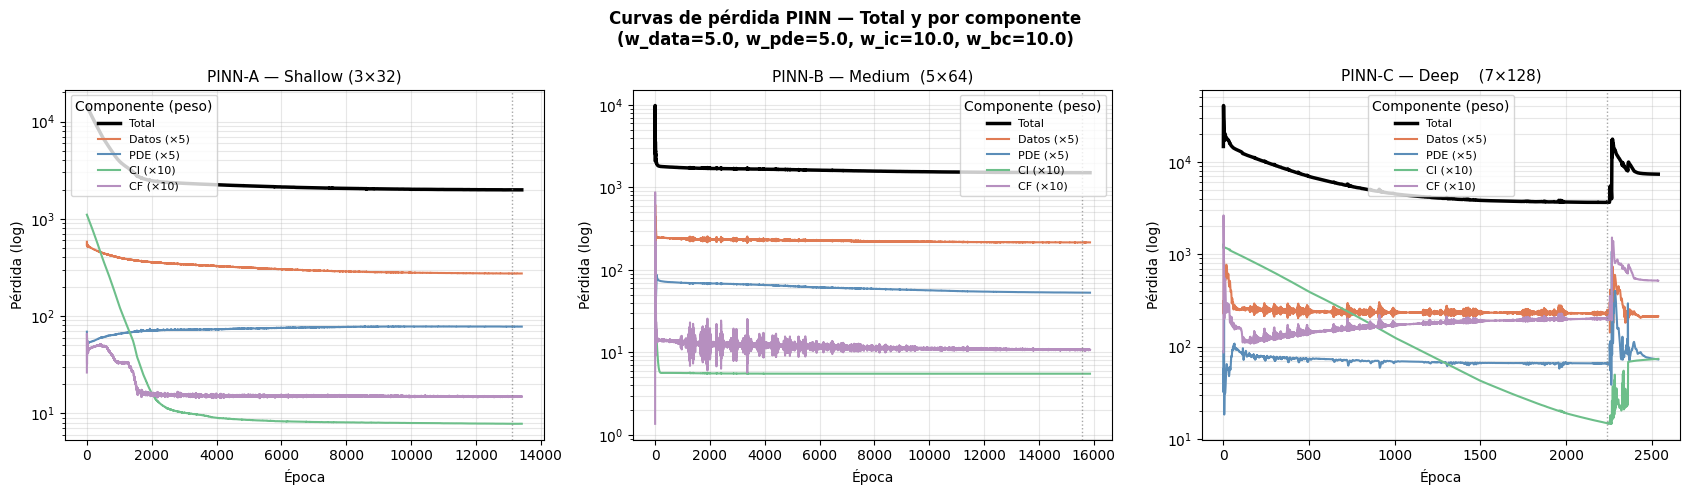

In [21]:
colores   = {'PINN_A': '#E07B54', 'PINN_B': '#5B8DB8', 'PINN_C': '#6DBF8A'}
etiquetas = {'PINN_A': 'PINN-A — Shallow (3×32)',
             'PINN_B': 'PINN-B — Medium  (5×64)',
             'PINN_C': 'PINN-C — Deep    (7×128)'}
col_comp  = {'total': 'black', 'data': '#E07B54',
             'pde':   '#5B8DB8', 'ic': '#6DBF8A', 'bc': '#B68FBF'}
lbl_comp  = {'total': 'Total', 'data': f'Datos (×{W_DATA:.0f})',
             'pde': f'PDE (×{W_PDE:.0f})',
             'ic':  f'CI (×{W_IC:.0f})',
             'bc':  f'CF (×{W_BC:.0f})'}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, nombre in zip(axes, historiales):
    hist = historiales[nombre]
    ep   = range(1, len(hist['total'])+1)

    for comp in ['total','data','pde','ic','bc']:
        lw = 2.5 if comp == 'total' else 1.5
        ax.semilogy(ep, hist[comp],
                    color=col_comp[comp], lw=lw,
                    label=lbl_comp[comp])

    best_ep = np.argmin(hist['total'])+1
    ax.axvline(best_ep, color='gray', lw=1, ls=':', alpha=0.7)

    ax.set_title(etiquetas[nombre], fontsize=11)
    ax.set_xlabel('Época', fontsize=10)
    ax.set_ylabel('Pérdida (log)', fontsize=10)
    ax.legend(fontsize=8, title='Componente (peso)')
    ax.grid(True, which='both', alpha=0.3)

fig.suptitle(
    f'Curvas de pérdida PINN — Total y por componente\n'
    f'(w_data={W_DATA}, w_pde={W_PDE}, w_ic={W_IC}, w_bc={W_BC})',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('pinn_perdida_componentes.png', dpi=150, bbox_inches='tight')
plt.show()

## Celda 9 — Gráfica 2: Predicción vs Valor analítico (scatter test)

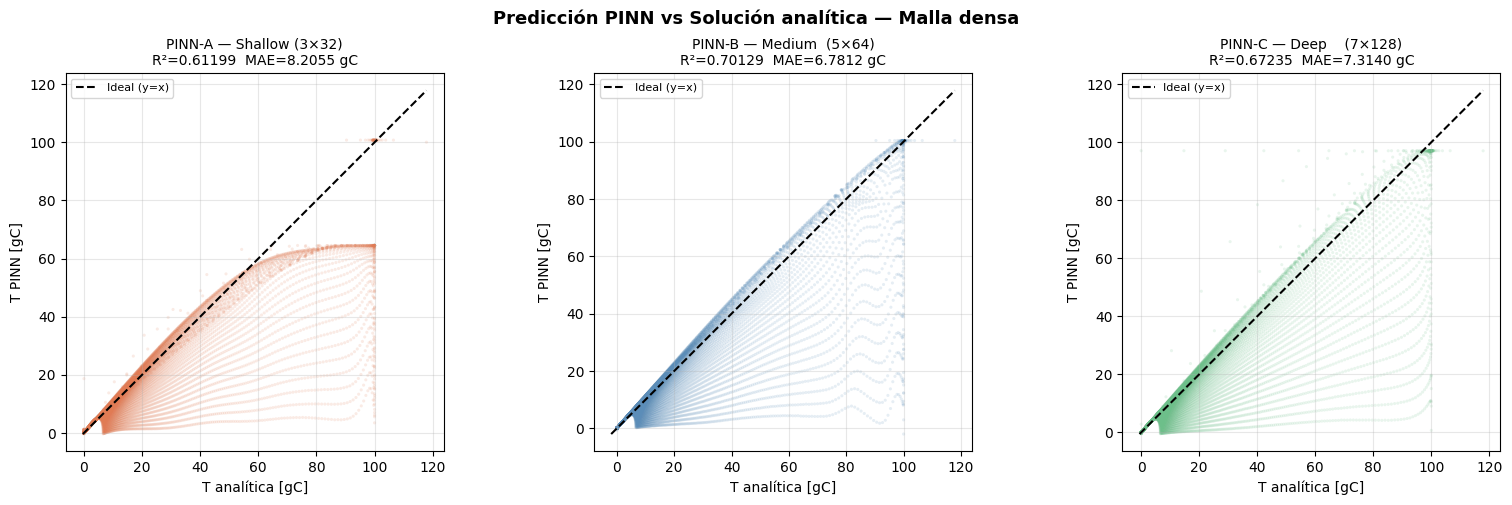

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, nombre in zip(axes, resultados):
    y_true = resultados[nombre]['y_true']
    y_pred = resultados[nombre]['y_pred']
    r2     = resultados[nombre]['R2']
    mae    = resultados[nombre]['MAE']
    col    = colores[nombre]

    ax.scatter(y_true, y_pred, alpha=0.15, s=5,
               color=col, edgecolors='none')

    lims = [min(y_true.min(), y_pred.min()),
            max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', lw=1.5, label='Ideal (y=x)')

    ax.set_xlabel('T analítica [gC]',  fontsize=10)
    ax.set_ylabel('T PINN [gC]',       fontsize=10)
    ax.set_title(f"{etiquetas[nombre]}\nR²={r2:.5f}  MAE={mae:.4f} gC", fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', 'box')

fig.suptitle('Predicción PINN vs Solución analítica — Malla densa',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pinn_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Celda 10 — Gráfica 3: Superficie predicha vs analítica en todo el dominio

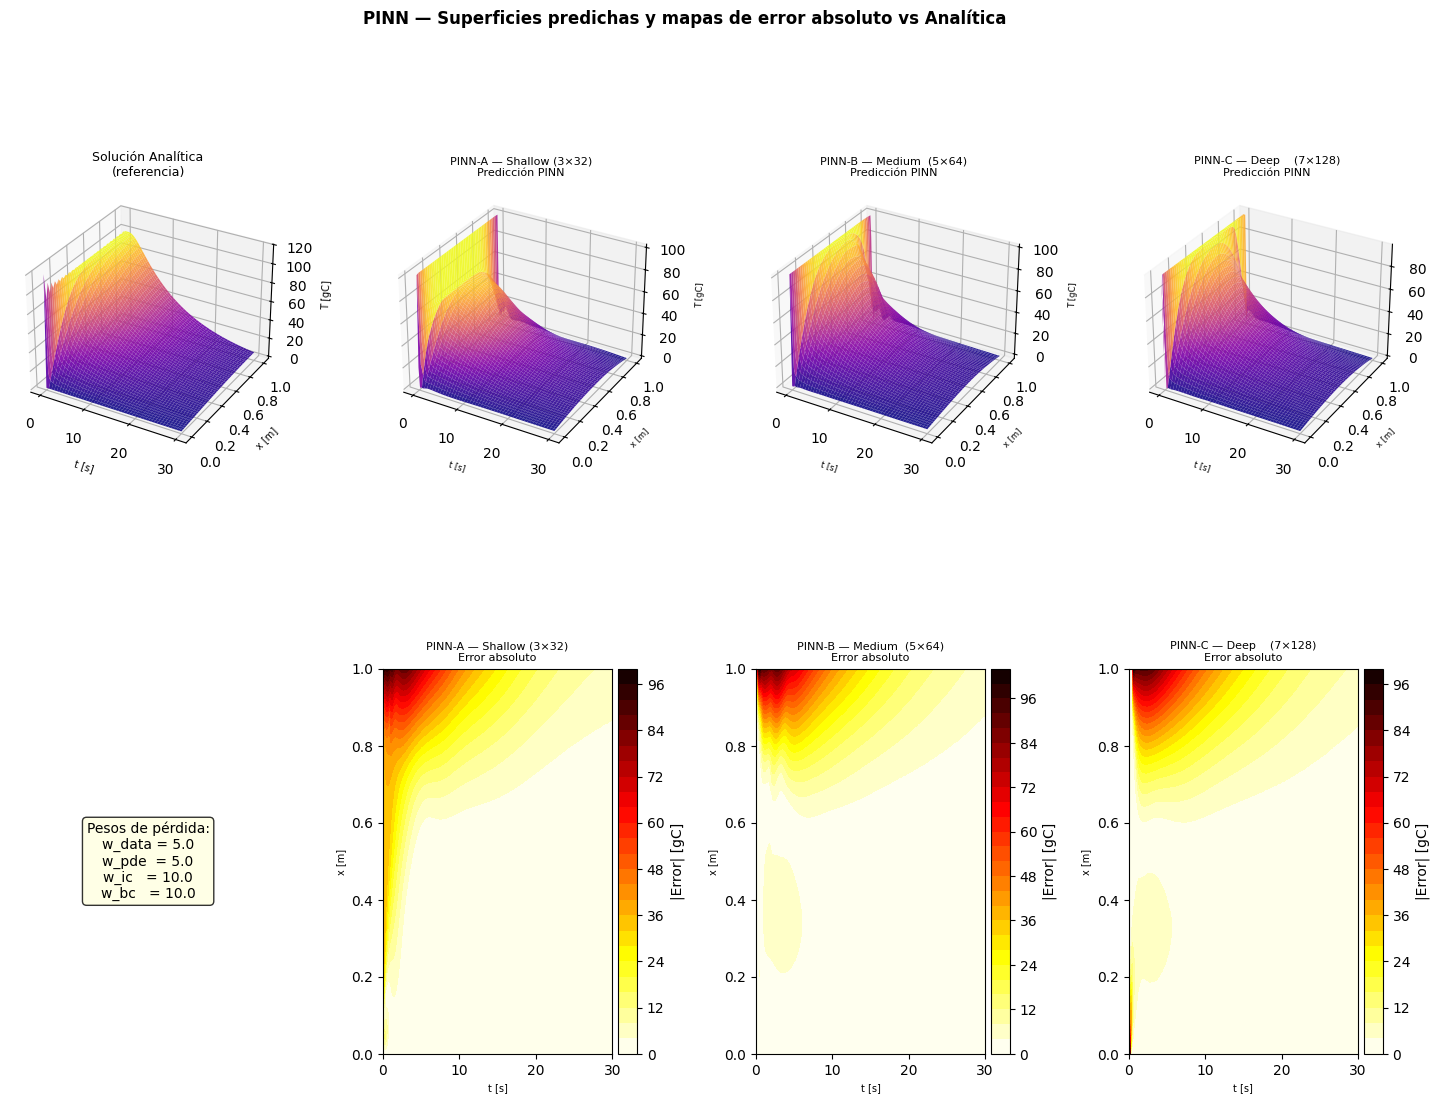

In [25]:
T_ref_malla = T_analitica(x_flat, t_flat).reshape(TT.shape)

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.4, wspace=0.35)

# ── Solución analítica de referencia ─────────────────────────
ax_ref = fig.add_subplot(gs[0, 0], projection='3d')
ax_ref.plot_surface(TT, XX, T_ref_malla, cmap=cm.plasma, alpha=0.9, linewidth=0)
ax_ref.set_title('Solución Analítica\n(referencia)', fontsize=9)
ax_ref.set_xlabel('t [s]', fontsize=7)
ax_ref.set_ylabel('x [m]', fontsize=7)
ax_ref.set_zlabel('T [gC]', fontsize=7)

# ── Tres PINN + mapas de error ────────────────────────────────
for col_idx, (nombre, modelo) in enumerate(
        zip(resultados.keys(), [model_A, model_B, model_C])):

    pred_malla = resultados[nombre]['pred_malla']
    err        = np.abs(pred_malla - T_ref_malla)

    # Superficie predicha
    ax_s = fig.add_subplot(gs[0, col_idx+1], projection='3d')
    ax_s.plot_surface(TT, XX, pred_malla, cmap=cm.plasma, alpha=0.9, linewidth=0)
    ax_s.set_title(f'{etiquetas[nombre]}\nPredicción PINN', fontsize=8)
    ax_s.set_xlabel('t [s]', fontsize=6)
    ax_s.set_ylabel('x [m]', fontsize=6)
    ax_s.set_zlabel('T [gC]', fontsize=6)

    # Mapa de error absoluto
    ax_e = fig.add_subplot(gs[1, col_idx+1])
    im   = ax_e.contourf(TT, XX, err, levels=25, cmap='hot_r')
    fig.colorbar(im, ax=ax_e, label='|Error| [gC]', pad=0.02)
    ax_e.set_title(f'{etiquetas[nombre]}\nError absoluto', fontsize=8)
    ax_e.set_xlabel('t [s]', fontsize=7)
    ax_e.set_ylabel('x [m]', fontsize=7)

# Celda vacía para la esquina inferior izquierda
ax_blank = fig.add_subplot(gs[1, 0])
ax_blank.axis('off')
ax_blank.text(0.5, 0.5,
    f'Pesos de pérdida:\n'
    f'w_data = {W_DATA}\nw_pde  = {W_PDE}\n'
    f'w_ic   = {W_IC}\nw_bc   = {W_BC}',
    ha='center', va='center', fontsize=10,
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

fig.suptitle('PINN — Superficies predichas y mapas de error absoluto vs Analítica',
             fontsize=12, fontweight='bold')
plt.savefig('pinn_superficies.png', dpi=150, bbox_inches='tight')
plt.show()

## Celda 11 — Gráfica 4: Perfiles T(x) en tiempos seleccionados

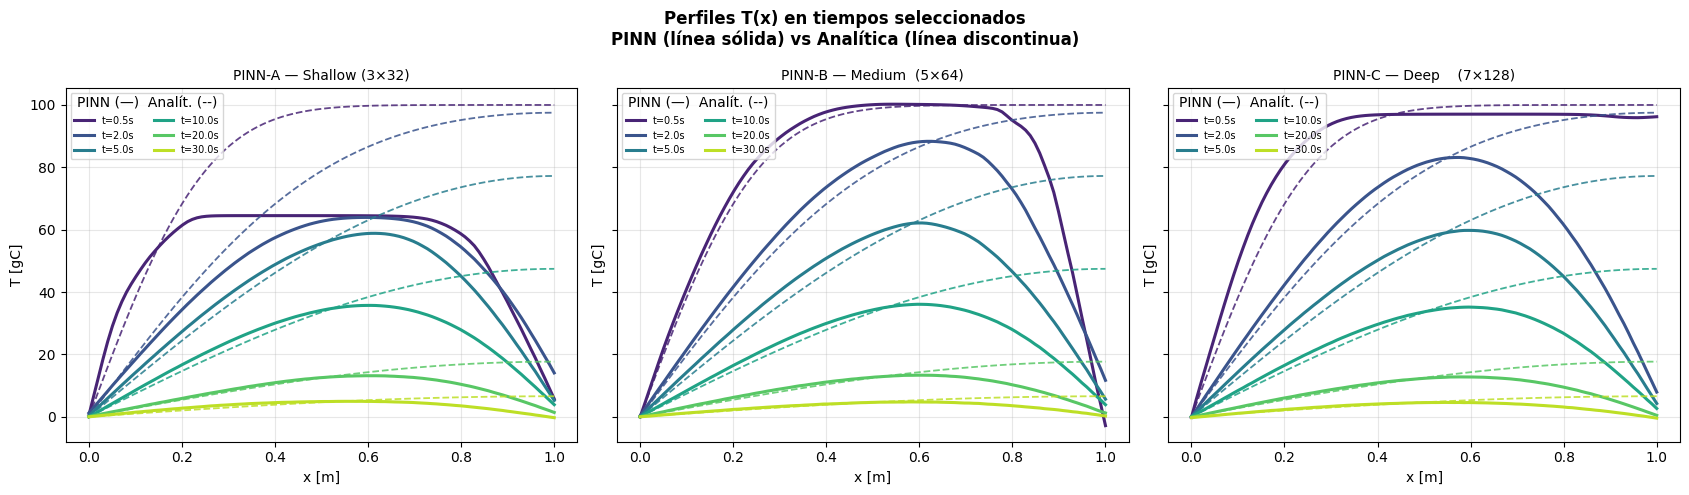

In [26]:
tiempos_eval = [0.5, 2.0, 5.0, 10.0, 20.0, 30.0]
x_prof       = np.linspace(0, L, 100).astype(np.float32)
colores_t    = plt.cm.viridis(np.linspace(0.1, 0.9, len(tiempos_eval)))

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)

for ax, (nombre, modelo) in zip(axes,
        zip(resultados.keys(), [model_A, model_B, model_C])):

    for t_ev, ct in zip(tiempos_eval, colores_t):
        # Solución analítica
        T_an = T_analitica(x_prof, t_ev)
        ax.plot(x_prof, T_an, '--', color=ct, lw=1.3, alpha=0.85)

        # Predicción PINN
        inp = np.column_stack([np.full_like(x_prof, t_ev), x_prof])
        pred = modelo.predict(inp, verbose=0).flatten()
        ax.plot(x_prof, pred, '-', color=ct, lw=2.2, label=f't={t_ev:.1f}s')

    ax.set_xlabel('x [m]',  fontsize=10)
    ax.set_ylabel('T [gC]', fontsize=10)
    ax.set_title(etiquetas[nombre], fontsize=10)
    ax.legend(fontsize=7, ncol=2, title='PINN (—)  Analít. (--)')
    ax.grid(True, alpha=0.3)

fig.suptitle('Perfiles T(x) en tiempos seleccionados\nPINN (línea sólida) vs Analítica (línea discontinua)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('pinn_perfiles_temp.png', dpi=150, bbox_inches='tight')
plt.show()

## Celda 12 — Gráfica 5: Evolución temporal en nodos seleccionados

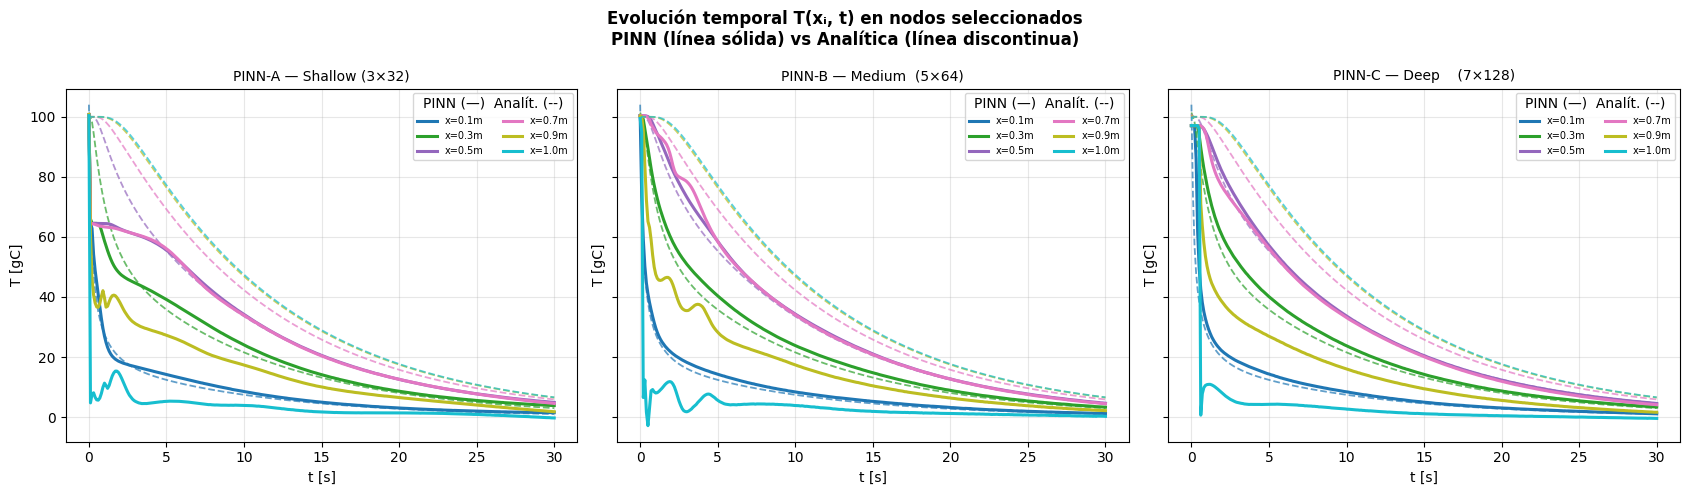

In [27]:
nodos_x  = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
t_evol   = np.linspace(0, T_MAX, 300).astype(np.float32)
col_nodo = plt.cm.tab10(np.linspace(0, 1, len(nodos_x)))

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)

for ax, (nombre, modelo) in zip(axes,
        zip(resultados.keys(), [model_A, model_B, model_C])):

    for xi, cn in zip(nodos_x, col_nodo):
        # Analítica
        T_an = np.array([T_analitica(np.array([xi]), t)[0] for t in t_evol])
        ax.plot(t_evol, T_an, '--', color=cn, lw=1.3, alpha=0.7)

        # PINN
        inp  = np.column_stack([t_evol, np.full_like(t_evol, xi)])
        pred = modelo.predict(inp, verbose=0).flatten()
        ax.plot(t_evol, pred, '-', color=cn, lw=2.2, label=f'x={xi:.1f}m')

    ax.set_xlabel('t [s]',  fontsize=10)
    ax.set_ylabel('T [gC]', fontsize=10)
    ax.set_title(etiquetas[nombre], fontsize=10)
    ax.legend(fontsize=7, ncol=2, title='PINN (—)  Analít. (--)')
    ax.grid(True, alpha=0.3)

fig.suptitle('Evolución temporal T(xᵢ, t) en nodos seleccionados\nPINN (línea sólida) vs Analítica (línea discontinua)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('pinn_evolucion_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

## Celda 13 — Gráfica 6: Residuo de la EDP en el dominio

Esta gráfica es **exclusiva de las PINN**: muestra qué tan bien satisface la red la ecuación de difusión $\partial_t T - \alpha^2 \partial_{xx}T = 0$ en cada punto del dominio.

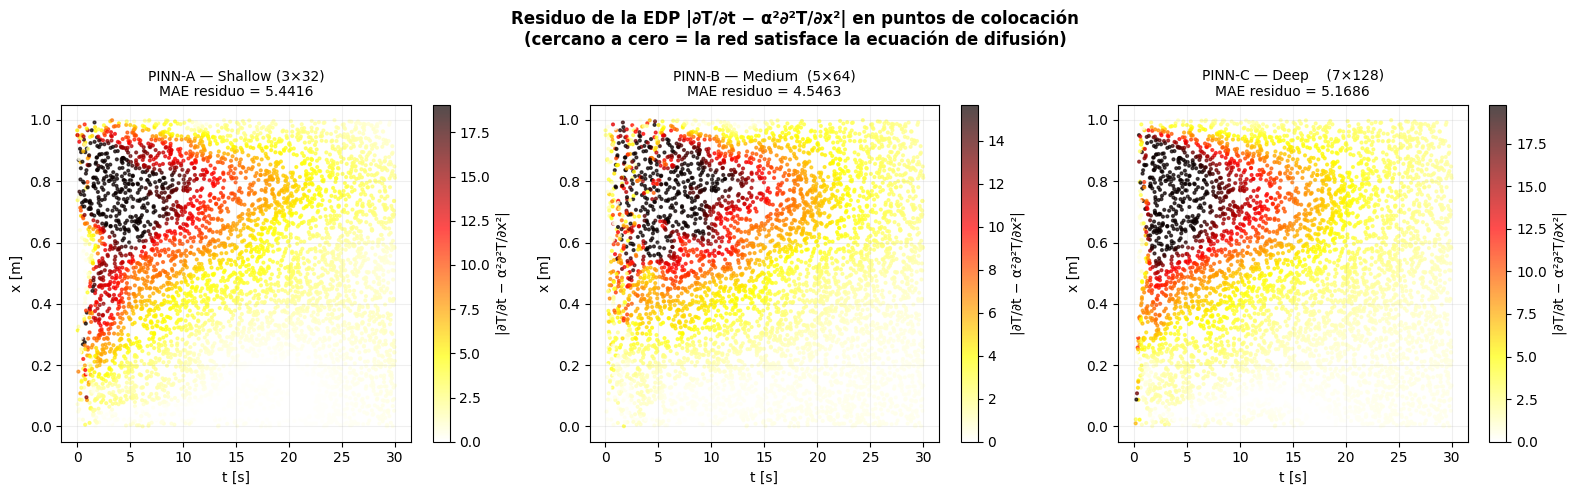

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (nombre, modelo) in zip(axes,
        zip(resultados.keys(), [model_A, model_B, model_C])):

    # Calcular residuo en malla densa
    res_vals = pinn_residual(modelo, t_coll_tf, x_coll_tf).numpy().flatten()

    sc = ax.scatter(t_coll, x_coll, c=np.abs(res_vals),
                    cmap='hot_r', s=4, alpha=0.7,
                    vmin=0, vmax=np.percentile(np.abs(res_vals), 95))
    plt.colorbar(sc, ax=ax, label='|∂T/∂t − α²∂²T/∂x²|')

    ax.set_xlabel('t [s]', fontsize=10)
    ax.set_ylabel('x [m]', fontsize=10)
    ax.set_title(
        f"{etiquetas[nombre]}\n"
        f"MAE residuo = {np.mean(np.abs(res_vals)):.4f}",
        fontsize=10
    )
    ax.grid(True, alpha=0.2)

fig.suptitle('Residuo de la EDP |∂T/∂t − α²∂²T/∂x²| en puntos de colocación\n'
             '(cercano a cero = la red satisface la ecuación de difusión)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('pinn_residuo_EDP.png', dpi=150, bbox_inches='tight')
plt.show()

## Celda 14 — Gráfica 7: Análisis de eficiencia (precisión vs costo)

Idéntica estructura a la DNN original — permite comparación directa.

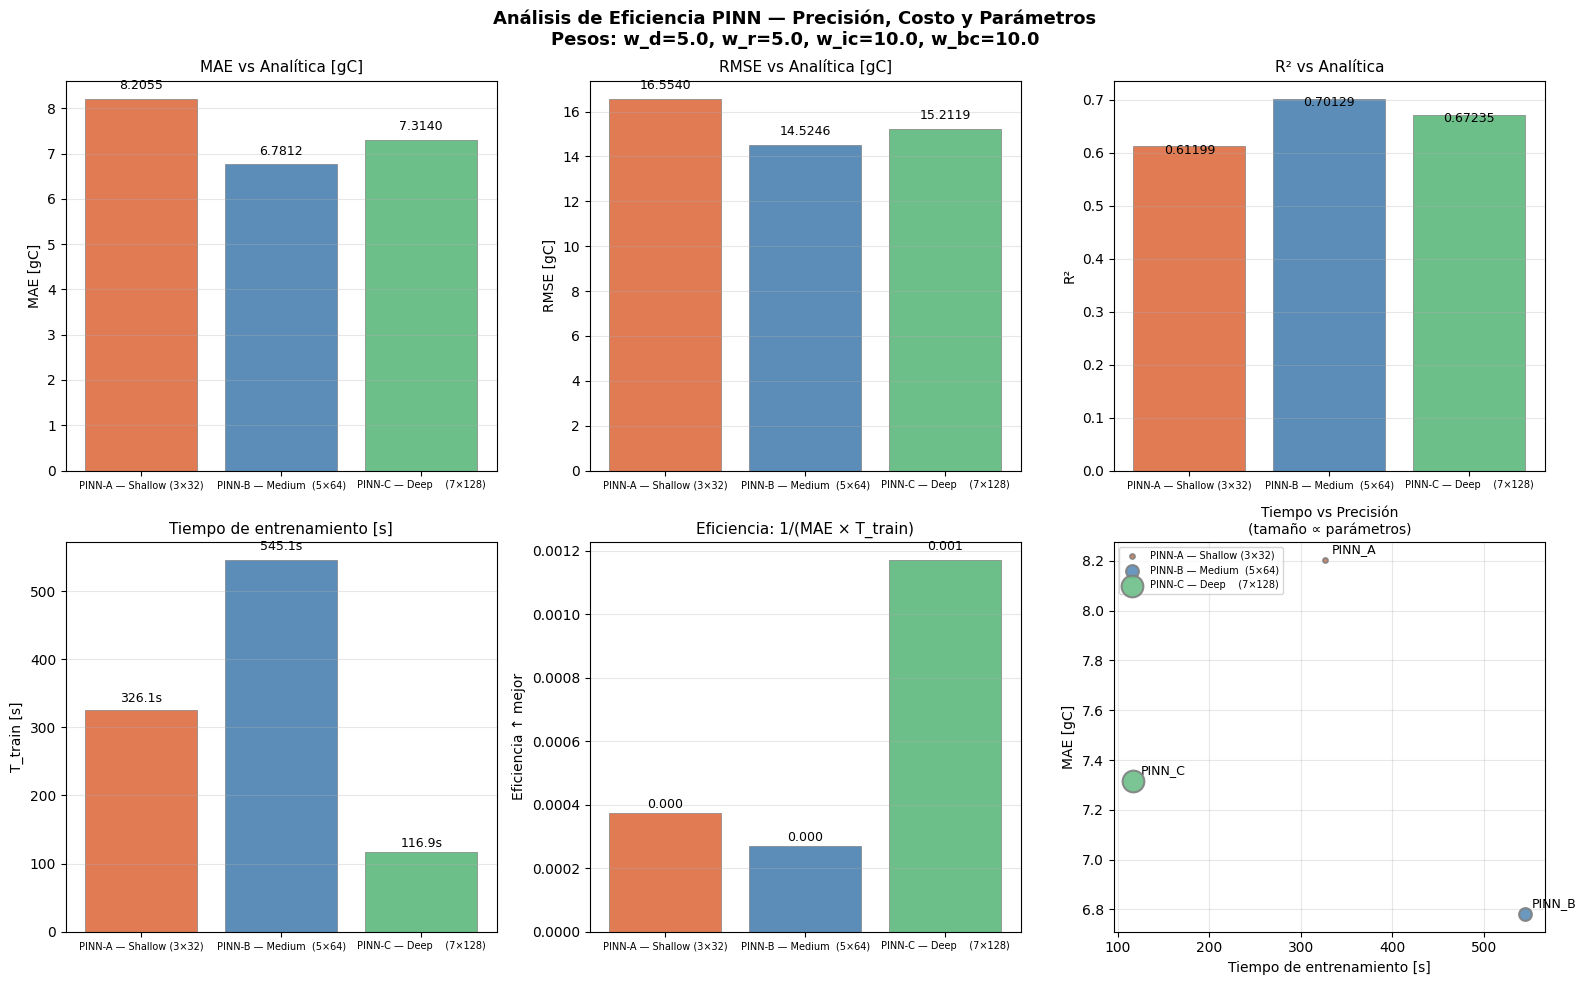

In [29]:
nombres   = list(resultados.keys())
maes      = [resultados[k]['MAE']           for k in nombres]
rmses     = [resultados[k]['RMSE']          for k in nombres]
r2s       = [resultados[k]['R2']            for k in nombres]
t_trains  = [resultados[k]['Tiempo_train']  for k in nombres]
params    = [resultados[k]['Params']        for k in nombres]
max_errs  = [resultados[k]['Max_Error']     for k in nombres]
cols_list = [colores[k] for k in nombres]
labs      = [etiquetas[k] for k in nombres]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# ── 1. MAE por modelo ─────────────────────────────────────────
bars = axes[0,0].bar(labs, maes, color=cols_list, edgecolor='gray', linewidth=0.5)
for b, v in zip(bars, maes):
    axes[0,0].text(b.get_x()+b.get_width()/2, v*1.02,
                   f'{v:.4f}', ha='center', va='bottom', fontsize=9)
axes[0,0].set_title('MAE vs Analítica [gC]', fontsize=11)
axes[0,0].set_ylabel('MAE [gC]')
axes[0,0].tick_params(axis='x', labelsize=7)
axes[0,0].grid(axis='y', alpha=0.3)

# ── 2. RMSE por modelo ────────────────────────────────────────
bars = axes[0,1].bar(labs, rmses, color=cols_list, edgecolor='gray', linewidth=0.5)
for b, v in zip(bars, rmses):
    axes[0,1].text(b.get_x()+b.get_width()/2, v*1.02,
                   f'{v:.4f}', ha='center', va='bottom', fontsize=9)
axes[0,1].set_title('RMSE vs Analítica [gC]', fontsize=11)
axes[0,1].set_ylabel('RMSE [gC]')
axes[0,1].tick_params(axis='x', labelsize=7)
axes[0,1].grid(axis='y', alpha=0.3)

# ── 3. R² por modelo ─────────────────────────────────────────
bars = axes[0,2].bar(labs, r2s, color=cols_list, edgecolor='gray', linewidth=0.5)
for b, v in zip(bars, r2s):
    axes[0,2].text(b.get_x()+b.get_width()/2, v - (1-min(r2s))*0.05,
                   f'{v:.5f}', ha='center', va='bottom', fontsize=9)
axes[0,2].set_title('R² vs Analítica', fontsize=11)
axes[0,2].set_ylabel('R²')
axes[0,2].tick_params(axis='x', labelsize=7)
axes[0,2].grid(axis='y', alpha=0.3)

# ── 4. Tiempo de entrenamiento ────────────────────────────────
bars = axes[1,0].bar(labs, t_trains, color=cols_list, edgecolor='gray', linewidth=0.5)
for b, v in zip(bars, t_trains):
    axes[1,0].text(b.get_x()+b.get_width()/2, v*1.02,
                   f'{v:.1f}s', ha='center', va='bottom', fontsize=9)
axes[1,0].set_title('Tiempo de entrenamiento [s]', fontsize=11)
axes[1,0].set_ylabel('T_train [s]')
axes[1,0].tick_params(axis='x', labelsize=7)
axes[1,0].grid(axis='y', alpha=0.3)

# ── 5. Eficiencia: 1/MAE por segundo de entrenamiento ────────
eficiencia = [1/(mae*t) for mae, t in zip(maes, t_trains)]
bars = axes[1,1].bar(labs, eficiencia, color=cols_list, edgecolor='gray', linewidth=0.5)
for b, v in zip(bars, eficiencia):
    axes[1,1].text(b.get_x()+b.get_width()/2, v*1.02,
                   f'{v:.3f}', ha='center', va='bottom', fontsize=9)
axes[1,1].set_title('Eficiencia: 1/(MAE × T_train)', fontsize=11)
axes[1,1].set_ylabel('Eficiencia ↑ mejor')
axes[1,1].tick_params(axis='x', labelsize=7)
axes[1,1].grid(axis='y', alpha=0.3)

# ── 6. Scatter: Tiempo vs MAE (tamaño = parámetros) ──────────
for k, col in zip(nombres, cols_list):
    axes[1,2].scatter(
        resultados[k]['Tiempo_train'],
        resultados[k]['MAE'],
        s=resultados[k]['Params']/200,
        color=col, edgecolors='gray', linewidth=1.5,
        alpha=0.9, label=etiquetas[k], zorder=5
    )
    axes[1,2].annotate(k,
        (resultados[k]['Tiempo_train'], resultados[k]['MAE']),
        textcoords='offset points', xytext=(5,5), fontsize=9
    )
axes[1,2].set_xlabel('Tiempo de entrenamiento [s]', fontsize=10)
axes[1,2].set_ylabel('MAE [gC]', fontsize=10)
axes[1,2].set_title('Tiempo vs Precisión\n(tamaño ∝ parámetros)', fontsize=10)
axes[1,2].legend(fontsize=7)
axes[1,2].grid(True, alpha=0.3)

fig.suptitle(
    f'Análisis de Eficiencia PINN — Precisión, Costo y Parámetros\n'
    f'Pesos: w_d={W_DATA}, w_r={W_PDE}, w_ic={W_IC}, w_bc={W_BC}',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('pinn_eficiencia_comparativa.png', dpi=150, bbox_inches='tight')
plt.show()

## Celda 15 — Gráfica 8: Convergencia comparada y descomposición de pérdida

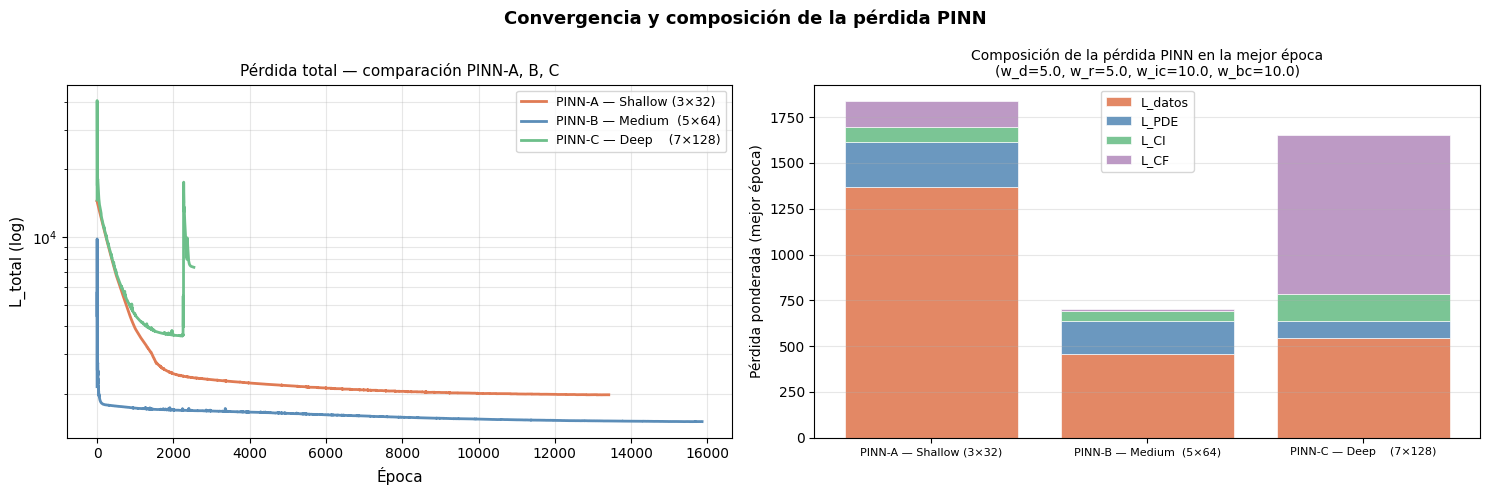

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Panel izquierdo: pérdida total de las 3 PINN ─────────────
for nombre, hist in historiales.items():
    ep = range(1, len(hist['total'])+1)
    axes[0].semilogy(ep, hist['total'],
                     color=colores[nombre], lw=2,
                     label=etiquetas[nombre])
axes[0].set_xlabel('Época', fontsize=11)
axes[0].set_ylabel('L_total (log)', fontsize=11)
axes[0].set_title('Pérdida total — comparación PINN-A, B, C', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True, which='both', alpha=0.3)

# ── Panel derecho: barra apilada de contribución por componente ──
labels_comp = ['L_datos', 'L_PDE', 'L_CI', 'L_CF']
data_comp   = np.array([
    [W_DATA * min(historiales[k]['data']),
     W_PDE  * min(historiales[k]['pde']),
     W_IC   * min(historiales[k]['ic']),
     W_BC   * min(historiales[k]['bc'])]
    for k in nombres
])

x_pos  = np.arange(len(nombres))
colors_comp = ['#E07B54', '#5B8DB8', '#6DBF8A', '#B68FBF']
bottom = np.zeros(len(nombres))

for j, (lc, cc) in enumerate(zip(labels_comp, colors_comp)):
    axes[1].bar(x_pos, data_comp[:,j], bottom=bottom,
                color=cc, edgecolor='white', lw=0.5, label=lc, alpha=0.9)
    bottom += data_comp[:,j]

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([etiquetas[k] for k in nombres], fontsize=8)
axes[1].set_ylabel('Pérdida ponderada (mejor época)', fontsize=10)
axes[1].set_title(
    f'Composición de la pérdida PINN en la mejor época\n'
    f'(w_d={W_DATA}, w_r={W_PDE}, w_ic={W_IC}, w_bc={W_BC})',
    fontsize=10
)
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

fig.suptitle('Convergencia y composición de la pérdida PINN',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pinn_convergencia_comparada.png', dpi=150, bbox_inches='tight')
plt.show()

## Celda 16 — Visualización de las arquitecturas PINN

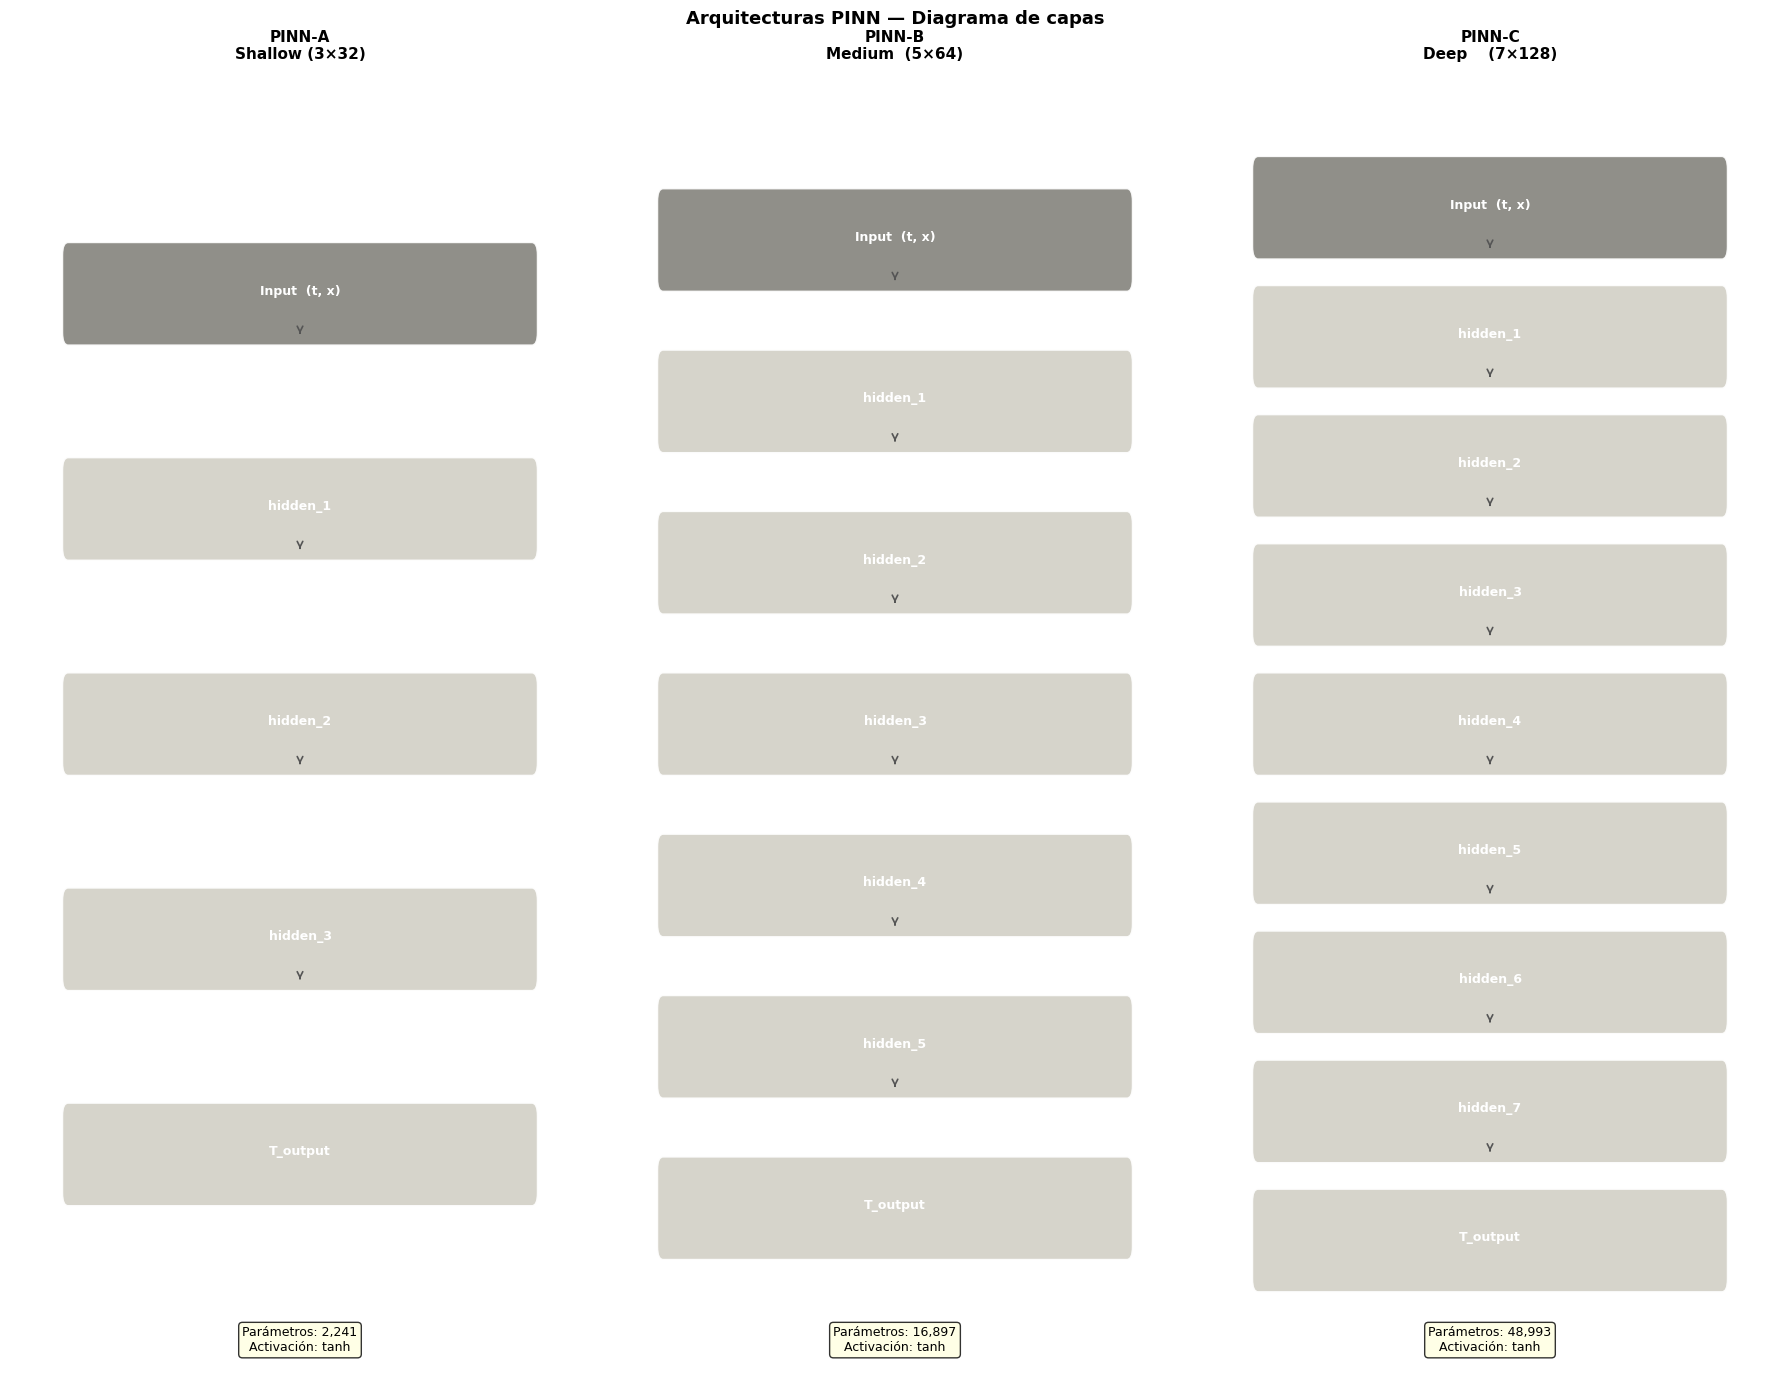

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 14))

arq_info = [
    ('PINN-A\nShallow (3×32)', model_A, '#7F77DD'),
    ('PINN-B\nMedium  (5×64)', model_B, '#D85A30'),
    ('PINN-C\nDeep    (7×128)', model_C, '#378ADD'),
]

for ax, (titulo, modelo, color_base) in zip(axes, arq_info):
    ax.axis('off')
    capas = [l for l in modelo.layers]
    n     = len(capas)
    y_step = 1.0 / (n + 1)

    for idx, capa in enumerate(capas):
        y    = 1.0 - (idx+1)*y_step
        cfg  = capa.get_config()
        name = capa.name

        if 'input' in name:
            color = '#888780'; texto = 'Input  (t, x)'
        elif 'dense' in name:
            units = cfg.get('units','?')
            act   = cfg.get('activation','')
            color = color_base
            texto = f'Dense {units}  |  {act}'
        else:
            color = '#D3D1C7'; texto = name

        rect = mpatches.FancyBboxPatch(
            (0.10, y-0.032), 0.80, 0.060,
            boxstyle='round,pad=0.01',
            facecolor=color, edgecolor='white',
            linewidth=1.5, alpha=0.93,
            transform=ax.transAxes, clip_on=False
        )
        ax.add_patch(rect)
        ax.text(0.50, y, texto,
                ha='center', va='center',
                fontsize=9, color='white', fontweight='bold',
                transform=ax.transAxes)

        # Flecha entre capas
        if idx < n-1:
            ax.annotate('', xy=(0.50, y-0.035),
                        xytext=(0.50, y-0.032+0.002),
                        xycoords='axes fraction',
                        textcoords='axes fraction',
                        arrowprops=dict(arrowstyle='->', color='#555', lw=1.2))

    ax.set_title(titulo, fontsize=11, fontweight='bold', pad=12)
    ax.text(0.50, 0.01,
            f'Parámetros: {modelo.count_params():,}\nActivación: tanh',
            ha='center', va='bottom', fontsize=9,
            transform=ax.transAxes,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

fig.suptitle('Arquitecturas PINN — Diagrama de capas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pinn_arquitecturas.png', dpi=150, bbox_inches='tight')
plt.show()

## Celda 17 — Ranking final y conclusión

In [31]:
df_final = pd.DataFrame({
    'Modelo'          : [etiquetas[k] for k in resultados],
    'Parámetros'      : [resultados[k]['Params']         for k in resultados],
    'Épocas'          : [resultados[k]['Epocas']         for k in resultados],
    'MAE [gC]'        : [round(resultados[k]['MAE'],   5) for k in resultados],
    'RMSE [gC]'       : [round(resultados[k]['RMSE'],  5) for k in resultados],
    'R²'              : [round(resultados[k]['R2'],    6) for k in resultados],
    'MaxErr [gC]'     : [round(resultados[k]['Max_Error'],3) for k in resultados],
    'T_train [s]'     : [round(resultados[k]['Tiempo_train'],2) for k in resultados],
    'L_final (min)'   : [round(resultados[k]['L_final'],6) for k in resultados],
})

df_final = df_final.sort_values('MAE [gC]').reset_index(drop=True)
df_final.index = df_final.index + 1
df_final.index.name = 'Rank'

print('\n' + '='*75)
print('  RANKING FINAL PINN — MENOR MAE = MEJOR MODELO')
print('='*75)
display(df_final)

mejor_mae = df_final.loc[1, 'Modelo']
mejor_r2  = df_final.loc[df_final['R²'].idxmax(), 'Modelo']

print(f'\n  Mejor modelo por MAE  : {mejor_mae}')
print(f'  Mejor modelo por R²   : {mejor_r2}')
print(f'\n  Configuración de pesos usada:')
print(f'    w_data = {W_DATA}  (datos numéricos)')
print(f'    w_pde  = {W_PDE}  (residuo EDP)')
print(f'    w_ic   = {W_IC} (condición inicial)')
print(f'    w_bc   = {W_BC} (condición de frontera)')
print()
print('  Archivos guardados:')
for f in [
    'pinn_perdida_componentes.png',
    'pinn_scatter.png',
    'pinn_superficies.png',
    'pinn_perfiles_temp.png',
    'pinn_evolucion_temporal.png',
    'pinn_residuo_EDP.png',
    'pinn_eficiencia_comparativa.png',
    'pinn_convergencia_comparada.png',
    'pinn_arquitecturas.png',
]:
    print(f'    {f}')


  RANKING FINAL PINN — MENOR MAE = MEJOR MODELO


,Modelo,Parámetros,Épocas,MAE [gC],RMSE [gC],R²,MaxErr [gC],T_train [s],L_final (min)
Rank,,,,,,,,,
1,PINN-B — Medium (5×64),16897,15859,6.78117,14.52463,0.701290,102.003998,545.13,1506.003906
2,PINN-C — Deep (7×128),48993,2538,7.31397,15.21193,0.672351,99.308998,116.92,3628.908447
3,PINN-A — Shallow (3×32),2241,13413,8.20547,16.55395,0.611989,96.522003,326.08,1982.375122



  Mejor modelo por MAE  : PINN-B — Medium  (5×64)
  Mejor modelo por R²   : PINN-B — Medium  (5×64)

  Configuración de pesos usada:
    w_data = 5.0  (datos numéricos)
    w_pde  = 5.0  (residuo EDP)
    w_ic   = 10.0 (condición inicial)
    w_bc   = 10.0 (condición de frontera)

  Archivos guardados:
    pinn_perdida_componentes.png
    pinn_scatter.png
    pinn_superficies.png
    pinn_perfiles_temp.png
    pinn_evolucion_temporal.png
    pinn_residuo_EDP.png
    pinn_eficiencia_comparativa.png
    pinn_convergencia_comparada.png
    pinn_arquitecturas.png
